In [1]:
# CELL 1
# Fleet AI - Exploratory Visualization

#Notebook này dùng để:
#- nạp dữ liệu Fleet đã được chuẩn hóa từ lõi mới `api/process_ai`
#- tạo các biểu đồ trực quan phục vụ phân tích và báo cáo
#- lưu hình tổng hợp `fleet_eda_panel.png` vào thư mục artifact của Fleet
#- hỗ trợ diễn giải mối quan hệ giữa tuổi xe, chi phí bảo trì, thời gian nằm xưởng và tần suất vào xưởng sửa chữa

#Notebook này chỉ phục vụ:
#- phân tích
#- trực quan hóa
#- trình bày báo cáo

#Logic lõi vẫn nằm trong:
#- `api.process_ai.entity.builders.fleet`
#- `api.process_ai.entity.trainers`
#- `api.process_ai.entity.inference`

In [2]:
# CELL 2
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import Image, display

from api.process_ai.entity.builders.fleet import (
    build_fleet_training_frame,
    default_fleet_task_spec,
)

sns.set_theme(style="darkgrid")

fleet_df = build_fleet_training_frame()
spec = default_fleet_task_spec()

print(f"Shape: {fleet_df.shape}")
fleet_df.head()

Shape: (3036, 128)


,truck_id,month,trips_completed,total_miles,total_revenue,average_mpg,maintenance_events,maintenance_cost,downtime_hours,utilization_rate,...,make_International,make_Kenworth,make_Mack,make_Peterbilt,make_Volvo,emergency_in_1m_count,emergency_in_2m_count,emergency_in_3m_count,target_next_3m_emergency_count,target_next_3m_emergency_maintenance
0,TRK00001,2022-01-01,22,39269,84792.02,6.78,2,4380.98,63.1,0.710,...,0,0,0,1,0,0,0,0,0,0
1,TRK00001,2022-02-01,27,40787,88809.05,6.23,0,0.00,0.0,0.964,...,0,0,0,1,0,0,0,0,0,0
2,TRK00001,2022-03-01,34,57422,120453.71,6.49,0,0.00,0.0,1.097,...,0,0,0,1,0,0,0,0,0,0
3,TRK00001,2022-04-01,20,34428,73531.28,6.50,2,3548.15,71.8,0.667,...,0,0,0,1,0,0,0,0,0,0
4,TRK00001,2022-05-01,16,20851,40791.53,6.38,1,1969.42,43.9,0.516,...,0,0,0,1,0,0,0,1,1,1


In [3]:
# CELL 3
df_plot = fleet_df.copy()

target_col = "target_next_3m_emergency_maintenance"
df_plot["fleet_rating"] = df_plot[target_col].astype(int)

# Tuổi xe
if "vehicle_age_years" not in df_plot.columns:
    if "model_year" in df_plot.columns and "month" in df_plot.columns:
        df_plot["vehicle_age_years"] = df_plot["month"].dt.year - df_plot["model_year"]
    else:
        df_plot["vehicle_age_years"] = 0

# Chi phí bảo trì
if "maintenance_cost" not in df_plot.columns:
    if "total_cost_sum_last_3m" in df_plot.columns:
        df_plot["maintenance_cost"] = df_plot["total_cost_sum_last_3m"]
    else:
        df_plot["maintenance_cost"] = 0.0

# Thời gian nằm xưởng
if "downtime_hours" not in df_plot.columns:
    if "downtime_hours_sum_last_3m" in df_plot.columns:
        df_plot["downtime_hours"] = df_plot["downtime_hours_sum_last_3m"]
    else:
        df_plot["downtime_hours"] = 0.0

# Tần suất vào xưởng
if "maint_frequency" not in df_plot.columns:
    if "maintenance_count_last_12m" in df_plot.columns:
        df_plot["maint_frequency"] = df_plot["maintenance_count_last_12m"]
    elif "maintenance_events" in df_plot.columns:
        df_plot["maint_frequency"] = df_plot["maintenance_events"]
    else:
        df_plot["maint_frequency"] = 0

plot_cols = [
    "truck_id",
    "month",
    "fleet_rating",
    "vehicle_age_years",
    "maintenance_cost",
    "downtime_hours",
    "maint_frequency",
]

df_plot[plot_cols].head()

,truck_id,month,fleet_rating,vehicle_age_years,maintenance_cost,downtime_hours,maint_frequency
0,TRK00001,2022-01-01,0,6,4380.98,63.1,2.0
1,TRK00001,2022-02-01,0,6,0.00,0.0,2.0
2,TRK00001,2022-03-01,0,6,0.00,0.0,2.0
3,TRK00001,2022-04-01,0,6,3548.15,71.8,4.0
4,TRK00001,2022-05-01,1,6,1969.42,43.9,5.0


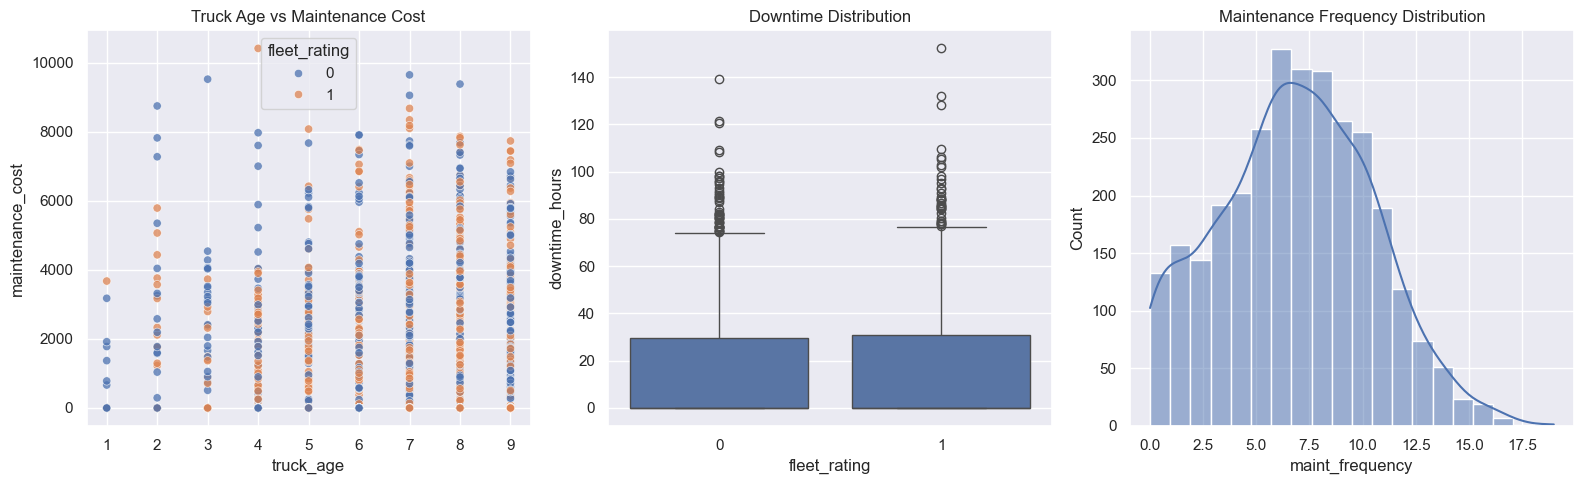

Đã lưu hình tại: D:\logistics_AI\model\entity_models\fleet\fleet_eda_panel.png


In [4]:
# CELL 4
save_path = Path(spec.artifact_dir) / "fleet_eda_panel.png"

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1) Tuổi xe vs chi phí bảo trì
sns.scatterplot(
    data=df_plot,
    x="vehicle_age_years",
    y="maintenance_cost",
    hue="fleet_rating",
    alpha=0.75,
    ax=axes[0],
)
axes[0].set_title("Truck Age vs Maintenance Cost")
axes[0].set_xlabel("truck_age")
axes[0].set_ylabel("maintenance_cost")

# 2) Phân bố thời gian nằm xưởng
sns.boxplot(
    data=df_plot,
    x="fleet_rating",
    y="downtime_hours",
    ax=axes[1],
)
axes[1].set_title("Downtime Distribution")
axes[1].set_xlabel("fleet_rating")
axes[1].set_ylabel("downtime_hours")

# 3) Tần suất vào xưởng sửa chữa
sns.histplot(
    data=df_plot,
    x="maint_frequency",
    bins=20,
    kde=True,
    ax=axes[2],
)
axes[2].set_title("Maintenance Frequency Distribution")
axes[2].set_xlabel("maint_frequency")
axes[2].set_ylabel("Count")

plt.tight_layout()
plt.savefig(save_path, dpi=180, bbox_inches="tight")
plt.show()

print(f"Đã lưu hình tại: {save_path}")

In [5]:
# CELL 5
summary_df = pd.DataFrame([
    {
        "artifact_name": "Fleet EDA Panel",
        "file_path": str(save_path),
        "purpose": "Hình trực quan hóa chính để đưa vào báo cáo Fleet AI",
    },
    {
        "artifact_name": "Entity Model Folder",
        "file_path": str(spec.artifact_dir),
        "purpose": "Thư mục chứa toàn bộ artifact của Fleet AI",
    },
    {
        "artifact_name": "Target Definition",
        "file_path": "target_next_3m_emergency_maintenance",
        "purpose": "Bài toán dự đoán xe có emergency maintenance trong 3 tháng tới",
    },
])

quick_stats = pd.DataFrame([
    {
        "rows": len(df_plot),
        "positive_rate": df_plot[target_col].mean(),
        "avg_truck_age": df_plot["vehicle_age_years"].mean(),
        "avg_maintenance_cost": df_plot["maintenance_cost"].mean(),
        "avg_downtime_hours": df_plot["downtime_hours"].mean(),
        "avg_maint_frequency": df_plot["maint_frequency"].mean(),
    }
])

print("=== QUICK FLEET SUMMARY ===")
display(quick_stats)

print("=== REPORT ARTIFACT SUMMARY ===")
display(summary_df)

=== QUICK FLEET SUMMARY ===


,rows,positive_rate,avg_truck_age,avg_maintenance_cost,avg_downtime_hours,avg_maint_frequency
0,3036,0.491765,7.006917,1304.384252,16.52612,6.804018


=== REPORT ARTIFACT SUMMARY ===


,artifact_name,file_path,purpose
0,Fleet EDA Panel,D:\logistics_AI\model\entity_models\fleet\flee...,Hình trực quan hóa chính để đưa vào báo cáo Fl...
1,Entity Model Folder,D:\logistics_AI\model\entity_models\fleet,Thư mục chứa toàn bộ artifact của Fleet AI
2,Target Definition,target_next_3m_emergency_maintenance,Bài toán dự đoán xe có emergency maintenance t...
